<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Part 1 (50 points)
In this part you will implement a neural network from scratch. You cannot use any existing
Deep Learning Framework. You can utilize NumPy and Pandas libraries to perform efficient
calculations. Refer to Lecture 5 slides for details on computations required.
Write a Class called NeuralNetwork that has at least the following methods (you are free to add
your own methods too):

a. Initialization method.

b. Forward propagation method that performs forward propagation calculations.

c. Backward propagation method that implements the backpropagation algorithm
discussed in class.

d. Train method that includes the code for gradient descent.

e. Cost method that calculates the loss function.

f. Predict method that calculates the predictions for the test set.

Test your NeuralNetwork Class with the dataset you selected. If the dataset is big, you may notice inefficiencies in runtime. Try incorporating different versions of gradient descent to improve that (Minibatch, Stochastic etc.). You may choose to use only a subset of your data for this task (or any other technique). Explain which technique you followed and why.

###Answer
I picked the [Fashion-MINIST](https://github.com/zalandoresearch/fashion-mnist). Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. We intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.
Each training and test example is assigned to one of the following labels:

| Label | Description |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Batch Gradient Descent (BGD) computes the gradient using the entire dataset before updating weights, ensuring stable convergence but slower updates. Stochastic Gradient Descent (SGD) updates weights after each individual sample, leading to faster learning but higher variance in updates. Mini-batch Gradient Descent (MBGD) strikes a balance by updating weights after a small batch of samples, combining the stability of BGD with the efficiency of SGD.

The results show that BGD converges slowly, reducing cost steadily but achieving only 59.00% accuracy in 7.30s since it updates weights after processing the entire dataset, making it computationally efficient but less adaptable to local minima. SGD, which updates weights after each sample, converges much faster in terms of cost reduction but is highly volatile; despite achieving 76.00% accuracy, it takes 217.40s, making it the least efficient. MBGD, which balances BGD's stability and SGD's speed by updating weights per small batch, achieves the best trade-off with 77.00% accuracy in 13.33s, making it the optimal choice due to its efficiency and superior generalization.

In [34]:
import numpy as np
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.W1 = np.random.randn(hidden_size, input_size) * 0.01
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * 0.01
        self.b2 = np.zeros((output_size, 1))

    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return expZ / np.sum(expZ, axis=0, keepdims=True)

    def softmax_derivative(self, A):
        # Using implicit differentiation, not directly needed here
        return A * (1 - A)

    def forward_propagation(self, X):
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = np.maximum(0, self.Z1)  # ReLU activation
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def cost(self, A2, Y):
        m = Y.shape[1]
        cost = -np.sum(Y * np.log(A2 + 1e-15)) / m
        return np.squeeze(cost)

    def backward_propagation(self, X, Y):
        m = X.shape[1]

        dZ2 = self.A2 - Y
        dW2 = (1 / m) * np.dot(dZ2, self.A1.T)
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = np.array(dA1, copy=True)
        dZ1[self.Z1 <= 0] = 0  # Derivative of ReLU
        dW1 = (1 / m) * np.dot(dZ1, X.T)
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

        self.dW1, self.db1, self.dW2, self.db2 = dW1, db1, dW2, db2

    def update_parameters(self):
        self.W1 -= self.learning_rate * self.dW1
        self.b1 -= self.learning_rate * self.db1
        self.W2 -= self.learning_rate * self.dW2
        self.b2 -= self.learning_rate * self.db2

    def train(self, X, Y, num_iterations, method="batch", batch_size=32):
        m = X.shape[1]

        for i in range(num_iterations):
            if method == "batch":
                self.forward_propagation(X)
                cost = self.cost(self.A2, Y)
                self.backward_propagation(X, Y)
                self.update_parameters()

            elif method == "stochastic":
                for j in range(m):
                    x_j = X[:, j:j+1]
                    y_j = Y[:, j:j+1]
                    self.forward_propagation(x_j)
                    cost = self.cost(self.A2, y_j)
                    self.backward_propagation(x_j, y_j)
                    self.update_parameters()

            elif method == "minibatch":
                permutation = np.random.permutation(m)
                X_shuffled = X[:, permutation]
                Y_shuffled = Y[:, permutation]
                num_minibatches = m // batch_size
                for k in range(num_minibatches):
                    start = k * batch_size
                    end = start + batch_size
                    X_mini = X_shuffled[:, start:end]
                    Y_mini = Y_shuffled[:, start:end]
                    self.forward_propagation(X_mini)
                    cost = self.cost(self.A2, Y_mini)
                    self.backward_propagation(X_mini, Y_mini)
                    self.update_parameters()

            if i % 50 == 0:
                print(f"Cost after iteration {i}: {cost}")

    def predict(self, X):
        A2 = self.forward_propagation(X)
        predictions = np.argmax(A2, axis=0)
        return predictions


In [35]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

#load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# use one-hot for multi-class
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("MINIST Dataset Scale:", X_train.shape, X_test.shape)

# use subset to save time 10%
train_indices = np.random.choice(X_train.shape[0], 600, replace=False)
X_train = X_train[train_indices].T
y_train = y_train[train_indices].T
test_indices = np.random.choice(X_train.shape[0], 100, replace=False)
X_test = X_test[test_indices].T
y_test = y_test[test_indices].T
print("MINIST Subset Scale:", X_train.shape, X_test.shape)

MINIST Dataset Scale: (60000, 784) (10000, 784)
MINIST Subset Scale: (784, 600) (784, 100)


In [38]:
import time
# compare these methods
methods = ["batch", "stochastic", "minibatch"]
results = {}
for method in methods:
    print(f"\nTraining with {method.capitalize()} Gradient Descent\n")
    nn = NeuralNetwork(input_size=X_train.shape[0], hidden_size=128, output_size=10, learning_rate=0.01)
    start_time = time.time()
    nn.train(X_train, y_train, num_iterations=500, method=method, batch_size=32)
    end_time = time.time()
    predictions = nn.predict(X_test)
    accuracy = np.mean(predictions == np.argmax(y_test, axis=0)) * 100
    results[method] = {"accuracy": accuracy, "time": end_time - start_time}
    print(f"{method.capitalize()} GD - Test accuracy: {accuracy:.2f}%, Time Taken: {end_time - start_time:.4f} seconds")


for method, result in results.items():
    print(f"{method.capitalize()} Gradient Descent - Accuracy: {result['accuracy']:.2f}%, Time: {result['time']:.4f}s")



Training with Batch Gradient Descent

Cost after iteration 0: 2.3027866689829146
Cost after iteration 100: 2.2522859755962594
Cost after iteration 200: 2.084488964582243
Cost after iteration 300: 1.755430441400766
Cost after iteration 400: 1.462020258648403
Batch GD - Test accuracy: 59.00%, Time Taken: 7.2985 seconds

Training with Stochastic Gradient Descent

Cost after iteration 0: 1.2616888826959822
Cost after iteration 100: 1.8934369415675898e-05
Cost after iteration 200: 5.0268780639777156e-06
Cost after iteration 300: 2.413584499838944e-06
Cost after iteration 400: 1.4351063274736646e-06
Stochastic GD - Test accuracy: 76.00%, Time Taken: 217.4015 seconds

Training with Minibatch Gradient Descent

Cost after iteration 0: 2.294773988971164
Cost after iteration 100: 0.44446121989189813
Cost after iteration 200: 0.39156434691373504
Cost after iteration 300: 0.13718734217981282
Cost after iteration 400: 0.16399133959322487
Minibatch GD - Test accuracy: 77.00%, Time Taken: 13.3325 sec

##Part 2 (50 points)
In this part you will implement a 2-layer neural network using any Deep Learning Framework
(e.g., TensorFlow, PyTorch etc.).
###Task 1 (5 points):
Assuming you are not familiar with the framework, in this part of the homework you will present your research describing the resources you used to learn the
framework (must include links to all resources). Clearly explain why you needed a particular resource for implementing a 2-layer Neural Network (NN). (Consider how you will keep track of all the computations in a NN i.e., what libraries/tools do you need within this framework.)

###Answer
To implement a 2-layer Neural Network in an unfamilia framework. I first found the [Introduction of NN by IBM](https://www.ibm.com/think/topics/neural-networks), [Research Survey](https://ieeexplore.ieee.org/abstract/document/9451544?casa_token=m2tghkk3ubsAAAAA:39tdKeHo7BAtk4kMRfGhfGr4G-jPPqGVCiJThSQGb-XoHzblmDJdEKrOR5thB8UsCDZCna4k) and a detailed instruction from [NN Source by Stanford](https://cs.stanford.edu/people/eroberts/courses/soco/projects/neural-networks/Sources/index.html). It is necessary to understand its syntax and workflow. The basic implementation specifics, such as layer definition, weight initialization, and activation functions, are all included.
Another is about the implement. The framework’s NN API guide and a video tutorial, I structured the model and implemented forward and backward propagation. To track computations and debug, we can refer to [TensorBoard](https://www.tensorflow.org/tensorboard?hl=zh-cn) for visualization, [PyTorch Autograd](https://pytorch.org/) for automatic differentiation, and [NumPy](https://numpy.org/) for efficient tensor operations. Other open sources are as follows.

Understanding the Framework:

https://www.tensorflow.org/guide

https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

Automatic Differentiation for Backpropagation:

https://www.tensorflow.org/guide/autodiff

https://www.tensorflow.org/api_docs/python/tf/GradientTape

https://pytorch.org/docs/stable/autograd.html

Building and Training Neural Networks:

https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

https://www.coursera.org/learn/neural-networks-deep-learning


###Task 2 (35 points):
Once you have figured out the resources you need for the project, you
should design and implement your project. The project must include the following steps (it’s not limited to these steps):
1. Exploratory Data Analysis (Can include data cleaning, visualization etc.)
2. Perform a train-dev-test split.
3. Implement forward propagation (clearly describe the activation functions and other
hyper-parameters you are using).
4. Compute the final cost function.
5. Implement gradient descent (any variant of gradient descent depending upon your
data and project can be used) to train your model. In this step it is up to you as someone
in charge of their project to improvise using optimization algorithms (Adams, RMSProp
etc.) and/or regularization. Experiment with normalized inputs i.e. comment on how
your model performs when the inputs are normalized.
6. Present the results using the test set.

NOTE: In this step, once you have implemented your 2-layer network you may increase and/or decrease the number of layers as part of the hyperparameter tuning process.

###Answer


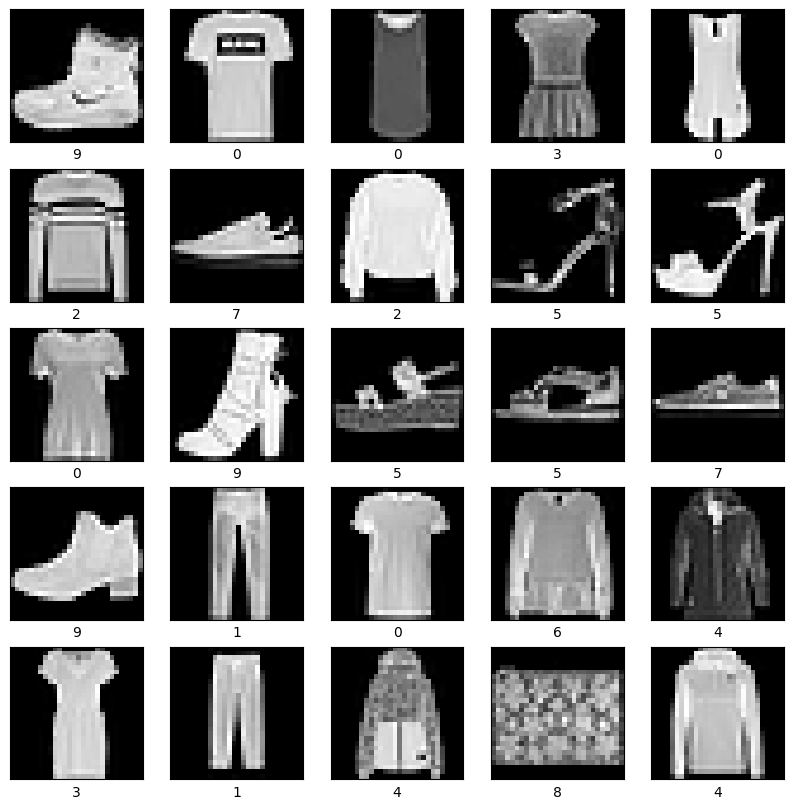

Train Full Shape: (60000, 28, 28)
Test Shape: (10000, 28, 28)
Label Distribution: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
train-dev-test split (48000, 28, 28) (12000, 28, 28) (10000, 28, 28)


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

# visualize some example images
def plot_sample_images(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i], cmap='gray')
        plt.xlabel(labels[i])
    plt.show()

#load full dataset
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
plot_sample_images(X_train_full, y_train_full)

print("Train Full Shape:", X_train_full.shape)
print("Test Shape:", X_test.shape)
print("Label Distribution:", np.bincount(y_train_full))

X_train_full, X_test = X_train_full / 255.0, X_test / 255.0

# split the data
X_train, X_dev, y_train, y_dev = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
print("train-dev-test split", X_train.shape, X_dev.shape, X_test.shape)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7678 - loss: 0.6558 - val_accuracy: 0.8611 - val_loss: 0.3858
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8642 - loss: 0.3773 - val_accuracy: 0.8655 - val_loss: 0.3679
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8722 - loss: 0.3471 - val_accuracy: 0.8710 - val_loss: 0.3464
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8819 - loss: 0.3214 - val_accuracy: 0.8727 - val_loss: 0.3445
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8887 - loss: 0.3018 - val_accuracy: 0.8778 - val_loss: 0.3379
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8973 - loss: 0.2808 - val_accuracy: 0.8760 - val_loss: 0.3434
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8997 - loss: 0.2686 - val_accuracy: 0.8813 - val_loss: 0.3289
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9030 - loss: 0.2548 

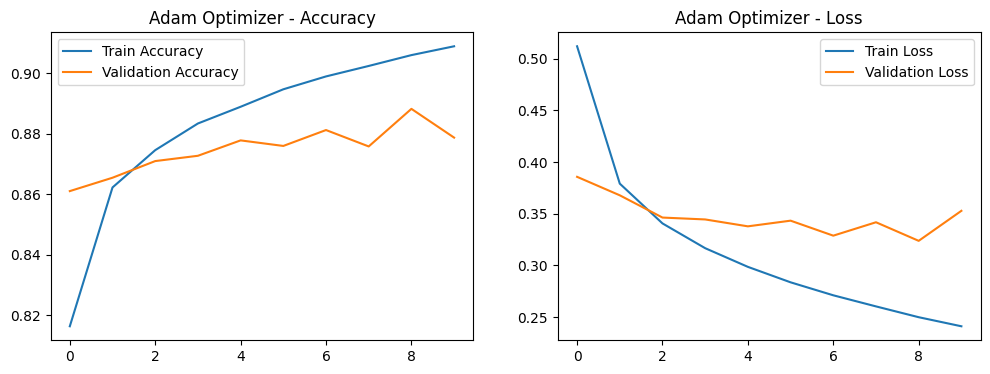

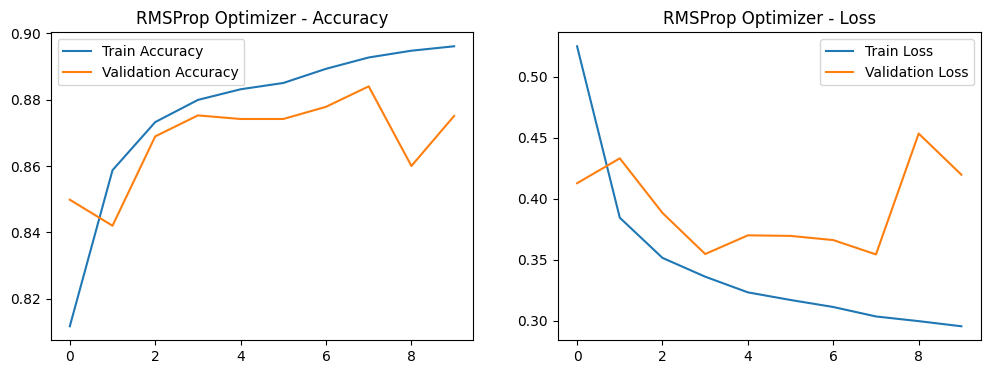

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop
# use sequential model
def build_and_compile_model(optimizer):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

adam_optimizer = Adam(learning_rate=0.001)
rmsprop_optimizer = RMSprop(learning_rate=0.001)

model_adam = build_and_compile_model(adam_optimizer)
model_rmsprop = build_and_compile_model(rmsprop_optimizer)

history_adam = model_adam.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_dev, y_dev))
history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_dev, y_dev))

test_accuracy_adam = model_adam.evaluate(X_test, y_test, verbose=0)[1]
test_accuracy_rmsprop = model_rmsprop.evaluate(X_test, y_test, verbose=0)[1]
print(f"Test accuracy with Adam: {test_accuracy_adam:.2f}")
print(f"Test accuracy with RMSProp: {test_accuracy_rmsprop:.2f}")

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_adam, "Adam Optimizer")
plot_history(history_rmsprop, "RMSProp Optimizer")

###Task 3 (10 points):
In task 2 describe how you selected the hyperparameters. What was the
rationale behind the technique you used? Did you use regularization? Why, or why not? Did you use an optimization algorithm? Why or why not?

###Answer
Selecting hyperparameters for neural network training is a combination of informed decision-making, experimentation, and leveraging well-established conventions. For the model, the Adam optimizer was chosen due to its efficiency and ability to adapt the learning rate on-the-fly. Adam is a popular choice as it combines advantages from both AdaGrad and RMSProp, which handle sparse gradients effectively and adjust learning rates during training. This optimizer minimizes the need for extensive learning rate tuning and is suitable for a wide array of problems. The default learning rate of 0.001 in Adam often provides a good starting point, allowing the model to converge steadily without manual adjustments.

The architecture of the neural network was deliberately designed with two hidden layers, containing 128 and 64 neurons respectively. This configuration strikes a balance between complexity and computational efficiency, offering sufficient capacity to capture the intrinsic patterns of a medium-complexity dataset like Fashion MNIST, while minimizing overfitting risks. The ReLU activation function was utilized for the hidden layers due to its simplicity and effectiveness in mitigating the vanishing gradient problem, thus facilitating a faster learning process. The batch size was set to 32, considering it is a widely used value that provides a good balance between convergence speed and computational stability, allowing the model to iterate quickly while maintaining gradient estimation quality.

Regularization was not explicitly applied in this example, as the primary focus was to establish a simple network capable of demonstrating a baseline performance. However, regularization techniques such as dropout or L2 regularization could be introduced should overfitting become a concern, especially when dealing with complex datasets or when more complex models require additional layers. The Adam optimizer was explicitly selected to enhance convergence speeds and manage dynamic learning rates, thus offering robustness against potential noisy gradients common in deeper networks. For future improvements, exploring hyperparameter search techniques like grid or randomized search, together with regularization strategies, could further enhance model performance and ensure its ability to generalize well on unseen data.

###Task 4 (100 points):
Create another baseline model (can be any model we covered so far except
a deep learning model). Using the same training data (as above) train your model and evaluate results using the test set. Compare the results of both models (the Neural Network and the baseline model). What are the reasons for one model performing better (or not) than the other? Explain.

###Answer
The Random Forest model and the neural network represent different approaches to classification. The Random Forest is an ensemble learning technique that aggregates multiple decision trees to improve stability and accuracy. It is often effective for datasets with non-linear boundaries and can handle both numerical and categorical data well. The model typically requires less data preprocessing compared to neural networks and can be a good starting point when building classification systems.

In contrast, the neural network uses multiple layers and activation functions to capture complex patterns. It's particularly suited for high-dimensional data like images due to its ability to learn hierarchical patterns. However, neural networks typically require more extensive preprocessing and training time compared to simpler models like Random Forests.

One model might outperform the other depending on the nature of the dataset, complexity of the task, and the amount of data available. For instance, neural networks may excel in scenarios with sufficient data where complex feature interactions exist, leveraging their depth and nonlinear transformations. Random Forests, on the other hand, might provide superior performance or faster convergence in situations where the dataset is smaller or feature interactions are simpler. The variance in performance is influenced by the inherent model complexities and the specific problem domain being addressed.

In [41]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

(X_full, y_full), (X_test, y_test) = fashion_mnist.load_data()

X_full = X_full.reshape(X_full.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

X_train, X_dev, y_train, y_dev = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_subset = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_subset, y_train)

y_test_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Random Forest Test accuracy: {rf_accuracy:.2f}")

Random Forest Test accuracy: 0.87


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7678 - loss: 0.6647 - val_accuracy: 0.8496 - val_loss: 0.4119
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8576 - loss: 0.3914 - val_accuracy: 0.8661 - val_loss: 0.3711
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8788 - loss: 0.3355 - val_accuracy: 0.8701 - val_loss: 0.3624
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8832 - loss: 0.3188 - val_accuracy: 0.8790 - val_loss: 0.3391
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8910 - loss: 0.2928 - val_accuracy: 0.8727 - val_loss: 0.3442
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8952 - loss: 0.2769 - val_accuracy: 0.8779 - val_loss: 0.3373
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8981 - loss: 0.2708 - val_accuracy: 0.8835 - val_loss: 0.3324
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9015 - loss: 0.2600

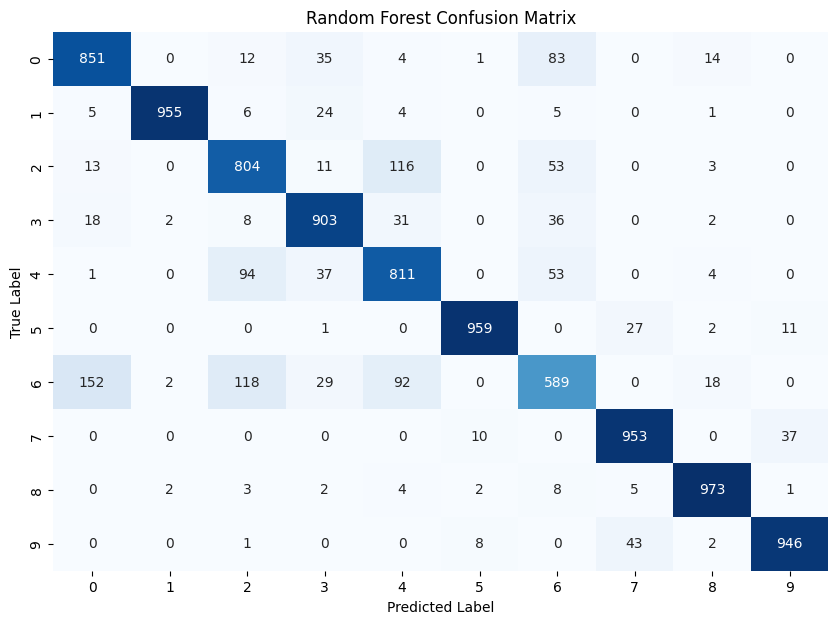

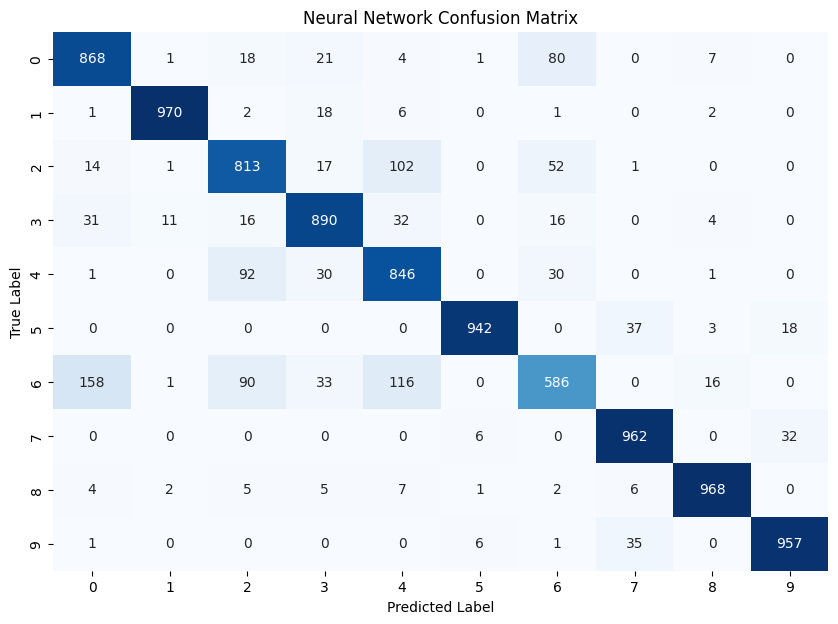

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

(X_full, y_full), (X_test, y_test) = fashion_mnist.load_data()

X_full = X_full / 255.0
X_test_nn = X_test / 255.0
X_test_rf = X_test.reshape(X_test.shape[0], -1) / 255.0

X_train, X_dev, y_train, y_dev = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_rf = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_rf_scaled = scaler.transform(X_test_rf)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

model = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten the images
    Dense(128, activation='relu'),  # Hidden layer
    Dense(64, activation='relu'),   # Another hidden layer
    Dense(10, activation='softmax') # Output layer for 10 classes
])

y_train_nn = to_categorical(y_train, 10)
y_dev_nn = to_categorical(y_dev, 10)
y_test_nn = to_categorical(y_test, 10)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train_nn, epochs=10, batch_size=32, validation_data=(X_dev, y_dev_nn))

rf_predictions = rf_model.predict(X_test_rf_scaled)
nn_predictions = np.argmax(model.predict(X_test_nn), axis=1)


rf_accuracy = accuracy_score(y_test, rf_predictions) * 100
nn_accuracy = accuracy_score(y_test, nn_predictions) * 100

print(f"Random Forest Test Accuracy: {rf_accuracy:.2f}%")
print(f"Neural Network Test Accuracy: {nn_accuracy:.2f}%")


def plot_confusion_matrix(true_labels, predictions, title):
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf_predictions, "Random Forest Confusion Matrix")

plot_confusion_matrix(y_test, nn_predictions, "Neural Network Confusion Matrix")